# 04 — Simulating TOA reflectance

This notebook demonstrates `SmartgSampler_Rho_toa_sym`, which computes the top-of-atmosphere reflectance $\rho_{toa}$ from a known surface $\rho_s$.

## How it works

The adjacency effect is characterised by the PSF (Point Spread Function) of the atmosphere: photons scattered sideways by aerosols arrive at the sensor from neighbouring pixels. Under the assumption that the PSF is **radially symmetric**, `SmartgSampler_Rho_toa_sym` exploits this structure:

1. It estimates the approximate radial profile of $\rho_{toa}$ from the input $\rho_s$.
2. It selects a small set of **adaptive radial sampling points** (by gradient-driven CDF inversion) — typically 50–100 points instead of the full 2D grid.
3. It runs a **single Smart-G simulation** with one sensor per radial sample point, yielding the TOA signal at each radius.
4. It reconstructs the full 2D $\rho_{toa}$ field from the radial profile via Pchip interpolation.

This reduces the number of photon transport simulations by several orders of magnitude compared to a pixel-by-pixel approach.

The underlying hypthesis is that the viewing zenith angle of the satellite (VZA) is close to nadir. In practice, the simulation remains valid for low Viewing Zenith Angles (<20°). Performances start to decrease significally over 50°. In order to perform exact simulation of the $\rho_{toa}$, please use the `SmartgSampler_Rho_toa`.

**Requires:** GPU + `SMARTG_DIR_AUXDATA`.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import adjeff
from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import S2Band, gaussian_image_dict
from adjeff.modules.samplers import SmartgSampler_Rho_toa_sym

assert "SMARTG_DIR_AUXDATA" in os.environ

## 4.1 — Setup: surface and atmospheric state

First, we setup a single atmosphere with 3 different Sentinel-2 bands, and a Gaussian surface reflectance map with a fixed $10~m$ resolution, a standard deviation of $3.0~km$ and a $(1001, 1001)$ input size.

In [ ]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

# Create a Gaussian surface (bright target, dark background)
scene = gaussian_image_dict(
    sigma=3.0,        # 300 m half-width
    res_km=0.01,      # 10 m resolution
    rho_min=0.05,
    rho_max=0.6,
    bands=BANDS,
    n=1001,
)

atmo = AtmoConfig(
    aot=xr.DataArray([0.6], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([0.0], dims=["vaa"]),
)

spectral = SpectralConfig.from_bands(BANDS)

## 4.2 — Run the TOA simulation

The TOA reflectance siulation can now be performed for each bands.

In [ ]:
module = SmartgSampler_Rho_toa_sym(
    atmo_config=atmo,
    geo_config=geo,
    remove_rayleigh=False,
    nr=80,           # number of radial sampling points
    n_ph=int(5e5),   # photons per sensor — increase for less noise
)

scene = module(scene)
print("Variables available after module:")
for var in scene[S2Band.B02].data_vars:
    print(f"  {var}: {list(scene[S2Band.B02][var].dims)}")

## 4.3 — Compare ρ_s and ρ_toa

Then, it is straighforward to compare the initial surface reflectance and the simulated TOA reflectance. 

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, band in enumerate(BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"].values
    rho_toa = ds["rho_toa"].squeeze().values

    coords = ds["rho_s"]
    extent = [
        float(coords.coords["x"].min()), float(coords.coords["x"].max()),
        float(coords.coords["y"].min()), float(coords.coords["y"].max()),
    ]
    vmax = max(rho_s.max(), rho_toa.max())

    for row, (data, title) in enumerate([(rho_s, "ρ_s"), (rho_toa, "ρ_toa")]):
        ax = axes[row, col]
        im = ax.imshow(data, origin="lower", extent=extent, vmin=0, vmax=vmax, cmap="YlOrBr")
        ax.set_title(f"{band.id} — {title}")
        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        plt.colorbar(im, ax=ax)

fig.suptitle("Surface vs TOA reflectance — AOT=0.2, SZA=30°", fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 — Radial profiles: quantifying the adjacency effect

A radial view is better for direct comparison. See how the contrast of the surface reflectance is decreased on TOA reflectance. The contrast on TOA reflectance gradually increase with the wavelength, as the AOT of the sulphate specie decrease with the AOT.

In [ ]:
fig, axes = plt.subplots(1, len(BANDS), figsize=(13, 4))

for ax, band in zip(axes, BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"]
    rho_toa = ds["rho_toa"].squeeze()

    profile_s = rho_s.adjeff.radial()
    profile_toa = rho_toa.adjeff.radial()

    ax.plot(profile_s.coords["r"], profile_s.values, label="ρ_s", color="steelblue")
    ax.plot(profile_toa.coords["r"], profile_toa.values, label="ρ_toa", color="tomato")
    ax.fill_between(
        profile_s.coords["r"],
        profile_s.values,
        profile_toa.values,
        alpha=0.2, color="tomato", label="adjacency contribution",
    )
    ax.set_title(f"{band.id} ({band.wl_nm:.0f} nm)")
    ax.set_xlabel("Radius [km]")
    ax.set_ylabel("Reflectance")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Radial profiles — adjacency effect (AOT=0.2, SZA=30°)", fontsize=12)
plt.tight_layout()
plt.show()

## 4.5 — Effect of AOT on the adjacency contribution

Effects of the AOT on the TOA reflectance can be simply studied with the following configuration. See how the contrast gradually decrease with the AOT.

In [ ]:
aot_test = [0.0, 0.20, 0.40, 0.60]
fig, ax = plt.subplots(figsize=(8, 5))

for aot_val in aot_test:
    atmo_test = AtmoConfig(
        aot=xr.DataArray([aot_val], dims=["aot"]),
        h=xr.DataArray([0.0], dims=["h"]),
        rh=xr.DataArray([50.0], dims=["rh"]),
        href=xr.DataArray([2.0], dims=["href"]),
        species={"sulphate": 1.0},
    )
    mod_test = SmartgSampler_Rho_toa_sym(
        atmo_config=atmo_test,
        geo_config=geo,
        remove_rayleigh=False,
        nr=80,
        n_ph=int(5e5),
    )
    scene_test = gaussian_image_dict(
        sigma=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
        bands=[S2Band.B02], n=1001,
    )
    scene_test = mod_test(scene_test)
    rho_toa = scene_test[S2Band.B02]["rho_toa"].squeeze()
    profile = rho_toa.adjeff.radial()
    ax.plot(profile.coords["r"], profile.values, label=f"AOT={aot_val}")

# Reference surface profile
rho_s_ref = gaussian_image_dict(
    sigma=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
    bands=[S2Band.B02], n=1001,
)[S2Band.B02]["rho_s"]
profile_s = rho_s_ref.adjeff.radial()
ax.plot(
    profile_s.coords["r"], 
    profile_s.values, 
    "k--", 
    label="ρ_s (true surface)", 
    linewidth=2,
)

ax.set_xlabel("Radius [km]")
ax.set_ylabel("ρ_toa (radial mean)")
ax.set_title("B02 — Effect of AOT on ρ_toa radial profile")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4.6 — 2D simulation: SmartgSampler_Rho_toa

`SmartgSampler_Rho_toa` lifts the radial symmetry assumption of the `_sym` variant. Instead of collapsing the scene to a 1D radial profile, it places `nx × ny` Smart-G sensors on an explicit pixel sub-grid and passes the full 2D reflectance map to Smart-G via an `Albedo_map` environment.

Key differences from `SmartgSampler_Rho_toa_sym`:
- Requires an **arbitrary** surface map (`analytical=False`); `SmartgSampler_Rho_toa_sym` raises a `ValueError` if an arbitrary field is passed.
- Sensors cover a rectangular sub-grid defined by `topleft_pix`, `nx`, `ny`; pixels outside are set to `NaN`.
- A companion boolean variable `rho_toa_valid` marks which pixels were computed.
- Valid at **any VZA**, including large viewing angles where the PSF is no longer circular.
- `rho_background` controls the `LambSurface` albedo used by Smart-G for photons that leave the `Albedo_map` region (`"mean"`, `"min"`, `"zero"`, or an explicit float — default `"mean"`).

In [2]:
from adjeff.modules.samplers import SmartgSampler_Rho_toa

BAND_2D = S2Band.B02

atmo_2d = AtmoConfig(
    aot=xr.DataArray([0.4], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)
geo_2d = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([0.0], dims=["vaa"]),
)

# analytical=False required by SmartgSampler_Rho_toa
scene_2d = gaussian_image_dict(
    sigma=5.0, res_km=0.5, rho_min=0.05, rho_max=0.6,
    bands=[BAND_2D], n=51, analytical=False,
)

sampler_2d = SmartgSampler_Rho_toa(
    atmo_config=atmo_2d,
    geo_config=geo_2d,
    remove_rayleigh=False,
    nx=51, ny=51,
    topleft_pix=(0, 0),
    n_ph=int(1e4),
    n_alb=10,
)
scene_2d = sampler_2d(scene_2d)

print("Variables in the 2D scene:")
for var in scene_2d[BAND_2D].data_vars:
    print(f"  {var}: {list(scene_2d[BAND_2D][var].dims)}")

2026-04-17 11:14:05 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-17 11:14:05 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=51 rho_max=0.6 rho_min=0.05 sigma=5.0 var=rho_s
2026-04-17 11:14:05 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=ea5a7271 module=SmartgSampler_Rho_toa
2026-04-17 11:14:05 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['species', 'sat_height'] scalars=['sza', 'vza'] vectors=['aot', 'rh', 'h', 'href']
2026-04-17 11:14:05 [debug    ] Initialization finshed.        arrays={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} deduplicated=False flat_dims=[]
2026-04-17 11:14:05 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=a931a102 module=SmartgSampler_Rho_atm
2026-04-17 11:14:05 [debug    ] Aggregated ConfigBundl

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-17 11:14:08 [info     ] rho_atm successfully calculated.
2026-04-17 11:14:08 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 1, 1, 1, 1, 1)
2026-04-17 11:14:08 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-17 11:14:08 [info     ] Computation finished           key=a931a102 module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-17 11:14:08 [info     ] Start rho_toa (2D) computation. band=S2Band.B02(490.0nm)
2026-04-17 11:14:08 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-17 11:14:08 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.4, rh=50.0, href=2.0, h=0.0
2026-04-17 11:14:08 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=26010000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-17 11:14:14 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 51, 51, 1, 1, 1, 1)
2026-04-17 11:14:14 [info     ] Computed rho_toa (2D).         band=S2Band.B02(490.0nm) dims=('vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h')
2026-04-17 11:14:14 [info     ] Computation finished           key=ea5a7271 module=SmartgSampler_Rho_toa vars=['rho_toa']
Variables in the 2D scene:
  rho_s: ['y', 'x']
  rho_atm: ['vza', 'sza', 'aot', 'rh', 'href', 'h']
  rho_toa: ['vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h']
  rho_toa_valid: ['y', 'x']


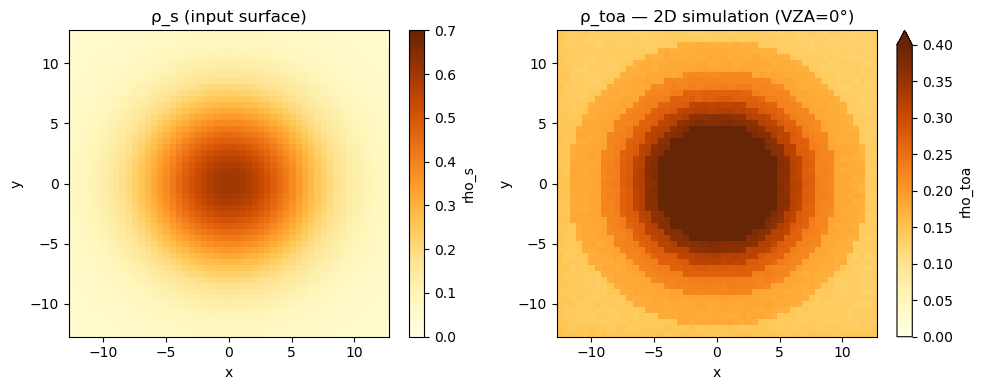

In [3]:
ds = scene_2d[BAND_2D]
rho_s_2d   = ds["rho_s"]
rho_toa_2d = ds["rho_toa"].squeeze()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
rho_s_2d.plot.imshow(ax=axes[0], cmap="YlOrBr", vmin=0.0, vmax=0.7)
axes[0].set_title("ρ_s (input surface)")
rho_toa_2d.plot.imshow(ax=axes[1], cmap="YlOrBr", vmin=0.0, vmax=0.4)
axes[1].set_title("ρ_toa — 2D simulation (VZA=0°)")
plt.tight_layout()
plt.show()

## 4.7 — Sym vs 2D: 2D error maps at VZA=0° and VZA=60°

At nadir (VZA=0°) the atmospheric PSF is radially symmetric, so `SmartgSampler_Rho_toa_sym` and `SmartgSampler_Rho_toa` should agree nearly everywhere — residuals reflect only Monte Carlo noise.

At VZA=60° the PSF elongates along the viewing direction. `SmartgSampler_Rho_toa_sym` still forces a circular profile, causing systematic spatial biases visible in the relative error map `(ρ_sym − ρ_2D) / ρ_2D`.

2026-04-17 11:15:55 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-17 11:15:55 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=51 rho_max=0.6 rho_min=0.0 sigma=1.5 var=rho_s
2026-04-17 11:15:55 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=27b7dc29 module=SmartgSampler_Rho_toa_sym
2026-04-17 11:15:55 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['species', 'sat_height'] scalars=['sza', 'vza'] vectors=['aot', 'rh', 'h', 'href']
2026-04-17 11:15:55 [debug    ] Initialization finshed.        arrays={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} deduplicated=False flat_dims=[]
2026-04-17 11:15:55 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=9ab3a86f module=SmartgSampler_Rho_atm
2026-04-17 11:15:55 [debug    ] Aggregated ConfigBu

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-17 11:15:58 [info     ] rho_atm successfully calculated.
2026-04-17 11:15:58 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 1, 1, 1, 1, 1)
2026-04-17 11:15:58 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-17 11:15:58 [info     ] Computation finished           key=9ab3a86f module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-17 11:15:58 [info     ] Start rho_toa computation.     band=S2Band.B02(490.0nm)
2026-04-17 11:15:58 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-17 11:15:58 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.4, rh=50.0, href=2.0, h=0.0
2026-04-17 11:15:58 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=100000000.0), Label(value='')), layout=Layout(align_items='center',…

There is no current context to clear.
2026-04-17 11:16:11 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 51, 51)
2026-04-17 11:16:11 [info     ] Computed rho_toa.              band=S2Band.B02(490.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-17 11:16:11 [info     ] Computation finished           key=27b7dc29 module=SmartgSampler_Rho_toa_sym vars=['rho_toa']
2026-04-17 11:16:11 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-17 11:16:11 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=51 rho_max=0.6 rho_min=0.0 sigma=1.5 var=rho_s
2026-04-17 11:16:11 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=f8795ae7 module=SmartgSampler_Rho_toa
2026-04-17 11:16:11 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['s

...

There is no current context to clear.
2026-04-17 11:16:59 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 51, 51)
2026-04-17 11:16:59 [info     ] Computed rho_toa.              band=S2Band.B02(490.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-17 11:16:59 [info     ] Computation finished           key=6cb4d9a7 module=SmartgSampler_Rho_toa_sym vars=['rho_toa']
2026-04-17 11:16:59 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-17 11:16:59 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=51 rho_max=0.6 rho_min=0.0 sigma=1.5 var=rho_s
2026-04-17 11:16:59 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=cf211fb1 module=SmartgSampler_Rho_toa
2026-04-17 11:16:59 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['s

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-17 11:17:02 [info     ] rho_atm successfully calculated.
2026-04-17 11:17:02 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 1, 1, 1, 1, 1)
2026-04-17 11:17:02 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-17 11:17:02 [info     ] Computation finished           key=13b72099 module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-17 11:17:02 [info     ] Start rho_toa (2D) computation. band=S2Band.B02(490.0nm)
2026-04-17 11:17:02 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 70.0} step=1/1
2026-04-17 11:17:02 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.4, rh=50.0, href=2.0, h=0.0
2026-04-17 11:17:02 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=26010000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-17 11:17:32 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 51, 51, 1, 1, 1, 1)
2026-04-17 11:17:32 [info     ] Computed rho_toa (2D).         band=S2Band.B02(490.0nm) dims=('vza', 'sza', 'y', 'x', 'aot', 'rh', 'href', 'h')
2026-04-17 11:17:32 [info     ] Computation finished           key=cf211fb1 module=SmartgSampler_Rho_toa vars=['rho_toa']


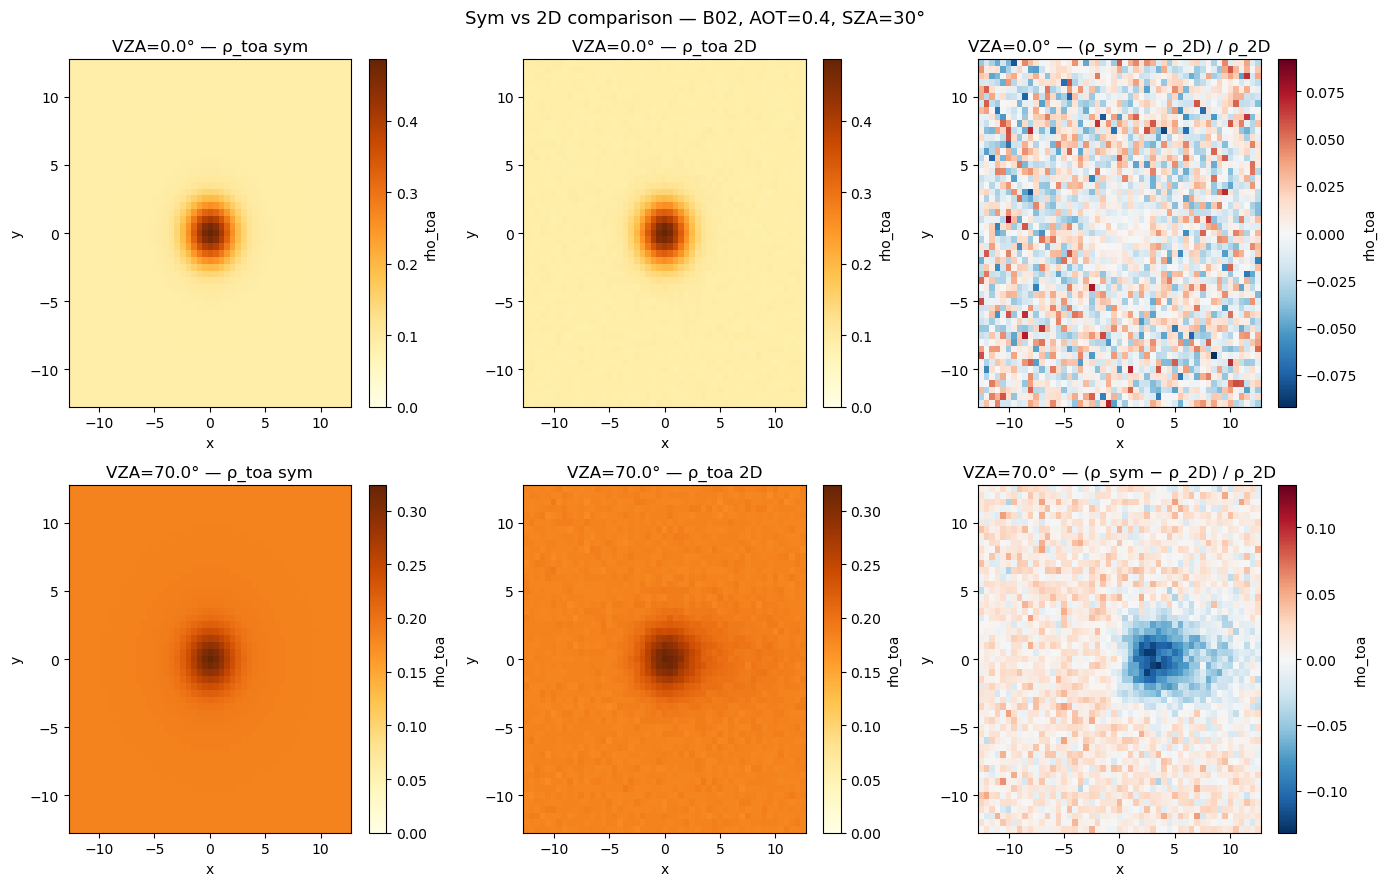

In [4]:
VZA_VALUES = [0.0, 70.0]
N_COMPARE = 51
SIGMA_COMPARE = 1.5

results = {}

for vza_val in VZA_VALUES:
    geo_v = GeoConfig(
        sza=xr.DataArray([30.0], dims=["sza"]),
        vza=xr.DataArray([vza_val], dims=["vza"]),
        saa=xr.DataArray([120.0], dims=["saa"]),
        vaa=xr.DataArray([180.0], dims=["vaa"]),
    )

    scene_sym = gaussian_image_dict(
        sigma=SIGMA_COMPARE, res_km=0.5, rho_min=0.0, rho_max=0.6,
        bands=[BAND_2D], n=N_COMPARE, analytical=True
    )
    sampler_sym_v = SmartgSampler_Rho_toa_sym(
        atmo_config=atmo_2d, geo_config=geo_v,
        remove_rayleigh=False, nr=50, n_ph=int(5e5),
    )
    scene_sym = sampler_sym_v(scene_sym)

    scene_2d_v = gaussian_image_dict(
        sigma=SIGMA_COMPARE, res_km=0.5, rho_min=0.0, rho_max=0.6,
        bands=[BAND_2D], n=N_COMPARE, analytical=False,
    )
    sampler_2d_v = SmartgSampler_Rho_toa(
        atmo_config=atmo_2d, geo_config=geo_v,
        remove_rayleigh=False, nx=N_COMPARE, ny=N_COMPARE,
        topleft_pix=(0, 0), n_ph=int(1e4), n_alb=1000,
        rho_background=0.0
    )
    scene_2d_v = sampler_2d_v(scene_2d_v)

    rho_sym = scene_sym[BAND_2D]["rho_toa"].squeeze()
    rho_2d  = scene_2d_v[BAND_2D]["rho_toa"].squeeze()
    rel_err = (rho_sym - rho_2d) / rho_2d
    results[vza_val] = (rho_sym, rho_2d, rel_err)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
col_titles = ["ρ_toa sym", "ρ_toa 2D", "(ρ_sym − ρ_2D) / ρ_2D"]

for row, vza_val in enumerate(VZA_VALUES):
    rho_sym, rho_2d, rel_err = results[vza_val]
    vmax = float(max(rho_sym.max(), rho_2d.max()))
    err_abs = float(abs(rel_err).max())

    for col, (data, cmap, vmin_c, vmax_c) in enumerate([
        (rho_sym, "YlOrBr", 0.0, vmax),
        (rho_2d,  "YlOrBr", 0.0, vmax),
        (rel_err, "RdBu_r", -err_abs, err_abs),
    ]):
        ax = axes[row, col]
        img = data.plot.imshow(ax=ax, cmap=cmap, vmin=vmin_c, vmax=vmax_c, add_colorbar=True)
        ax.set_title(f"VZA={vza_val}° — {col_titles[col]}")

fig.suptitle(
    f"Sym vs 2D comparison — {BAND_2D.id}, AOT=0.4, SZA=30°", fontsize=13
)
plt.tight_layout()
plt.show()